In [12]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
import numpy as np
%matplotlib inline

In [13]:
# read all the words
words = open("names.txt", "r").read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [14]:
# build the vocbulary of characters and mappings to/from integers
chars = sorted(list(set("".join(words))))
stoi = {s : i + 1 for i, s in enumerate(chars)}
stoi["."] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [15]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):
  X, Y = [], []

  for w in words:
    context = [0] *block_size
    for ch in w + ".":
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1]) # 80%
Xdev, Ydev = build_dataset(words[n1:n2]) #10%
Xte, Yte = build_dataset(words[n2:]) # 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [16]:
# MLP revisited
n_embd = 10 # the dimensitonality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproductibility
C = torch.randn((vocab_size, n_embd),             generator = g)
W1 = torch.randn((n_embd*block_size, n_hidden),   generator = g) * (5/3)/((n_embd * block_size)**0.5)
b1 = torch.randn(n_hidden,                        generator = g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),          generator = g) * 0.01
b2 = torch.randn(vocab_size,                      generator = g) * 0

parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters)) #number of parameters in total
for p in parameters:
  p.requires_grad = True

11897


tensor(0.0086) tensor(1.0049)
tensor(-0.0015) tensor(0.9980)


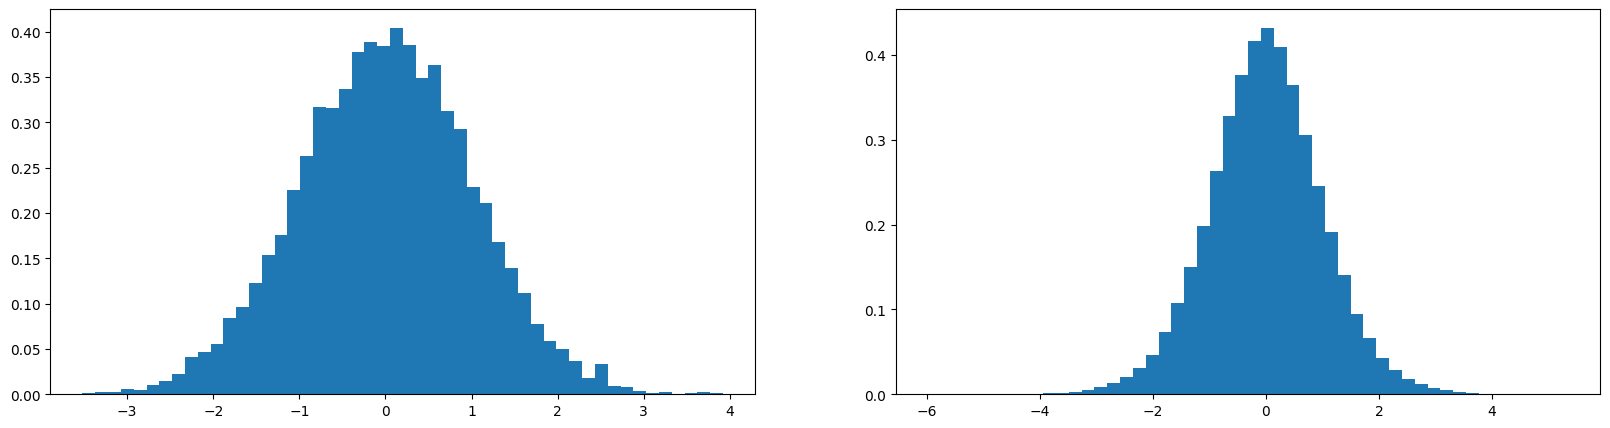

In [17]:
x = torch.randn(1000,10)
w = torch.randn(10,200) / 10**0.5
y = x @ w
print(x.mean(), x.std())
print(y.mean(), y.std())
plt.figure(figsize = (20,5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(), 50, density = True);
plt.subplot(122)
plt.hist(y.view(-1).tolist(), 50, density = True);

refer the paper by Kaiming He to understand how to better intiialize weights and biases.
https://www.youtube.com/redirect?event=video_description&redir_token=QUFFLUhqbWtPWV90TnlWWWhTZFk4UWVJSUtQbHRsZUJyZ3xBQ3Jtc0ttY0FaQmdESHlyWGdNdFctbXprZUMwcC1OWnNxSTd4MzlQWDc0Nl9JQ1VWNUtwc0xfeFB5RVhVZUlMN21UUTFhNUtSaW9YM2NNQ20xcUJjUUZrc1JEd083TUVObjBnVE14b05QVDVjWTBuZ0VPOVlxVQ&q=https%3A%2F%2Farxiv.org%2Fabs%2F1502.01852&v=P6sfmUTpUmc

for tanh  we use $std = (5/3)/\sqrt{fan in}$

### Not so important with modern normalization and optimization methods!!

In [19]:
# same optimization as last notebook'
max_steps = 200000
batch_size =32
lossi = []

for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator = g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X, Y

  #forward pass
  emb = C[Xb]
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
  hpreact = embcat @ W1 + b1 # hidden layer pre-activation
  h = torch.tanh(hpreact) #hidden layer
  logits = h @W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb) # loss function

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  lr = 0.1 if i <100000 else 0.01
  for p in parameters:
    p.data += -lr *p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f"{i:7d}/{max_steps: 7d}: {loss.item():.4f}")
  lossi.append(loss.log10().item())

  #break

      0/ 200000: 3.3179
  10000/ 200000: 2.1910
  20000/ 200000: 2.3270
  30000/ 200000: 2.5396
  40000/ 200000: 1.9468
  50000/ 200000: 2.3331
  60000/ 200000: 2.3852
  70000/ 200000: 2.1173
  80000/ 200000: 2.3159
  90000/ 200000: 2.2010
 100000/ 200000: 1.8591
 110000/ 200000: 2.0881
 120000/ 200000: 1.9389
 130000/ 200000: 2.3913
 140000/ 200000: 2.0949
 150000/ 200000: 2.1458
 160000/ 200000: 1.7824
 170000/ 200000: 1.7249
 180000/ 200000: 1.9752
 190000/ 200000: 1.8614


In [20]:
h.shape

torch.Size([32, 200])

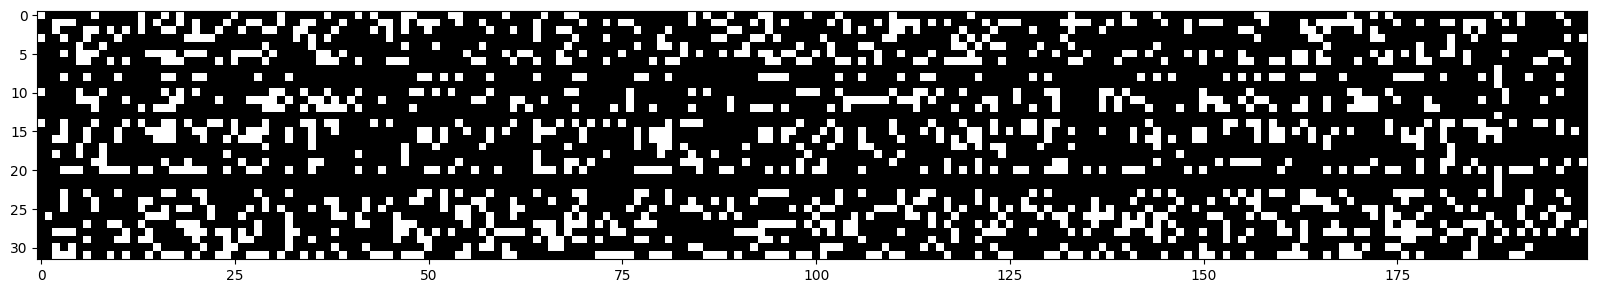

In [21]:
plt.figure(figsize = (20,10))
plt.imshow(h.abs() > 0.99, cmap ="gray", interpolation = "nearest") # white for true

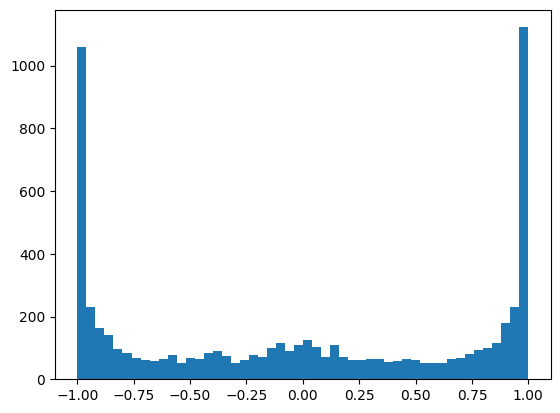

In [22]:
plt.hist(h.view(-1).tolist(), 50);

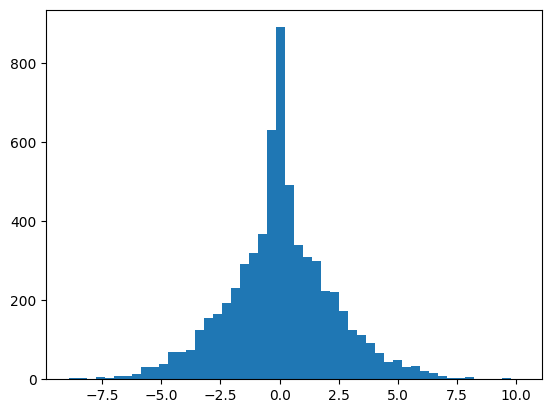

In [23]:
plt.hist(hpreact.view(-1).tolist(), 50);

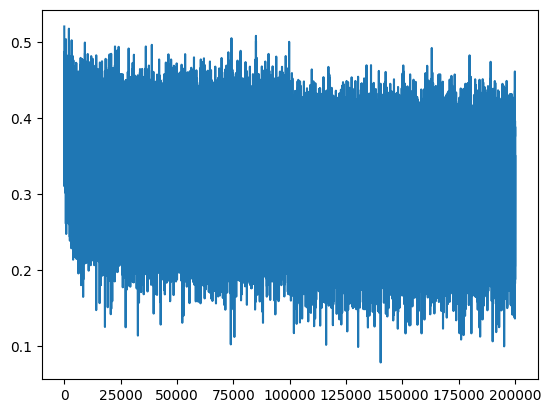

In [24]:
plt.plot(lossi)

In [25]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
    x, y = {
        "train" : (Xtr, Ytr),
        "val": (Xdev, Ydev),
        "test": (Xte, Yte),
    }[split]

    emb = C[x] # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
    h = torch.tanh(embcat @ W1 + b1) #(N, n_hidden)
    logits = h @ W2 + b2 # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss("train")
split_loss("val")

train 2.0376644134521484
val 2.106989622116089


In [26]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20): # drawing 20 samples

    out = []  # stores the samples
    context = [0]*block_size # initialize with all ...
    while True:
        # forward pass the neural net:
        emb = C[torch.tensor([context])] # (1, block_size, n_embd)
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @W2 + b2
        probs = F.softmax(logits, dim = 1)
        # sample from the distribution
        ix = torch.multinomial(probs, num_samples = 1, generator = g).item()
        # shift the context window and track the samples
        context= context[1:] + [ix]
        out.append(ix)
        #if we sample the special "." token, break
        if ix == 0:
            break
    print("".join(itos[i] for i in out)) # decode and print the generated word

carmahzaylyn.
kiffinleige.
tyrencessa.
jazon.
nadelynn.
jareei.
nellara.
chaiivan.
legyn.
ham.
joce.
quint.
salin.
alianni.
waveron.
jaryxin.
kaellissa.
med.
edi.
abette.


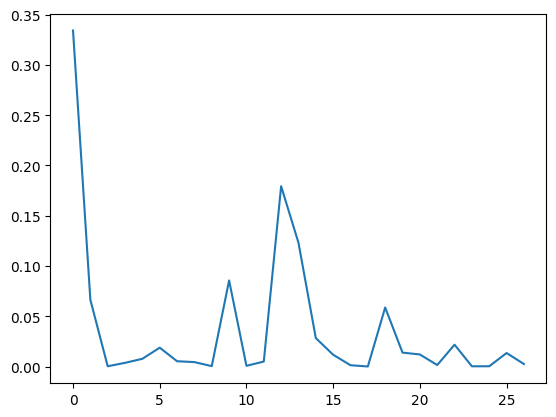

In [ ]:
plt.plot(probs.detach().numpy()[0])

In [ ]:
-torch.tensor(1/27.0).log()

tensor(3.2958)

In [27]:
logits = torch.randn(4)
probs = torch.softmax(logits, dim = 0)
loss = -probs[2].log()
logits, probs, loss

(tensor([ 0.3469,  0.0438,  0.5054, -1.1920]),
 tensor([0.3200, 0.2363, 0.3750, 0.0687]),
 tensor(0.9809))

Batch normalization



batch mean: $$\mu_B = 1/m \sum_{i =1}^{m} x_i$$
batch variance: $$\sigma_B^2 = 1/m \sum_{i =1}^{m} (x_i - \mu_B)^2$$
Normalize: $$\hat{x_i} \leftarrow \frac{x_i - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}$$
Scale and shift: $$y_i \leftarrow \gamma * \hat{x_i} + \beta = BN_{\gamma, \beta}(x_i)$$
parameters: $$\gamma, \beta$$

In [32]:
# MLP revisited
n_embd = 10 # the dimensitonality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproductibility
C = torch.randn((vocab_size, n_embd),             generator = g)
W1 = torch.randn((n_embd*block_size, n_hidden),   generator = g) * (5/3)/((n_embd * block_size)**0.5)
b1 = torch.randn(n_hidden,                        generator = g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),          generator = g) * 0.01
b2 = torch.randn(vocab_size,                      generator = g) * 0

# for batch norm initialization we have a gain set to 1 and a bias set to 0
bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) #number of parameters in total
for p in parameters:
  p.requires_grad = True

12297


In [33]:
# same optimization as last notebook'
max_steps = 200000
batch_size =32
lossi = []

for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator = g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X, Y

  #forward pass
  emb = C[Xb]
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
  hpreact = embcat @ W1 + b1 # hidden layer pre-activation
  hpreact = bngain * (hpreact - hpreact.mean(0,keepdim = True )) / hpreact.std(0, keepdim = True) + bnbias
  h = torch.tanh(hpreact) #hidden layer
  logits = h @W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb) # loss function

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  lr = 0.1 if i <100000 else 0.01
  for p in parameters:
    p.data += -lr *p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f"{i:7d}/{max_steps: 7d}: {loss.item():.4f}")
  lossi.append(loss.log10().item())

  #break

      0/ 200000: 3.3147
  10000/ 200000: 2.1984
  20000/ 200000: 2.3375
  30000/ 200000: 2.4359
  40000/ 200000: 2.0119
  50000/ 200000: 2.2595
  60000/ 200000: 2.4775
  70000/ 200000: 2.1020
  80000/ 200000: 2.2788
  90000/ 200000: 2.1862
 100000/ 200000: 1.9474
 110000/ 200000: 2.3010
 120000/ 200000: 1.9837
 130000/ 200000: 2.4523
 140000/ 200000: 2.3839
 150000/ 200000: 2.1987
 160000/ 200000: 1.9733
 170000/ 200000: 1.8668
 180000/ 200000: 1.9973
 190000/ 200000: 1.8347


In [35]:
# calibrate the bratch norm at the end of the training

with torch.no_grad():
    # pass the training set through
    emb = C[Xtr]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    # measure the mean and std over the entire training set
    bnmean = hpreact.mean(0, keepdim = True)
    bnstd = hpreact.std(0, keepdim = True)

In [37]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
    x, y = {
        "train" : (Xtr, Ytr),
        "val": (Xdev, Ydev),
        "test": (Xte, Yte),
    }[split]

    emb = C[x] # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
    hpreact = embcat @ W1 + b1
    #hpreact = bngain * (hpreact - hpreact.mean(0,keepdim = True )) / hpreact.std(0, keepdim = True) + bnbias
    hpreact = bngain *(hpreact - bnmean) / bnstd + bnbias
    h = torch.tanh(hpreact) #(N, n_hidden)
    logits = h @ W2 + b2 # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss("train")
split_loss("val")

train 2.0668270587921143
val 2.1049270629882812


In [28]:
hpreact.shape

torch.Size([32, 200])

In [30]:
hpreact.mean(0, keepdim= True).shape

torch.Size([1, 200])

In [31]:
hpreact.std(0, keepdim = True).shape

torch.Size([1, 200])

### 3
Calculating running mean and running Std from batch norm
We use batch norm so that the pre activation does not go far off from a unit gaussian and we have larger concentration near the 0 and hence not lose information during backprop

In [39]:
# MLP revisited
n_embd = 10 # the dimensitonality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproductibility
C = torch.randn((vocab_size, n_embd),             generator = g)
W1 = torch.randn((n_embd*block_size, n_hidden),   generator = g) * (5/3)/((n_embd * block_size)**0.5)
b1 = torch.randn(n_hidden,                        generator = g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),          generator = g) * 0.01
b2 = torch.randn(vocab_size,                      generator = g) * 0

bngain = torch.ones([1, n_hidden])
bnbias = torch.zeros([1, n_hidden])
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) #number of parameters in total
for p in parameters:
  p.requires_grad = True

12297


In [40]:
# same optimization as last notebook' 
max_steps = 200000
batch_size =32
lossi = []

for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator = g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X, Y

  #forward pass
  emb = C[Xb]
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
  hpreact = embcat @ W1 + b1 # hidden layer pre-activation
  bnmeani = hpreact.mean(0, keepdim = True)
  bnstdi = hpreact.std(0, keepdim = True)
  hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias

  with torch.no_grad():
    bnmean_running = 0.999*bnmean_running + 0.001*bnmeani
    bnstd_running = 0.999*bnstd_running + 0.001*bnstdi

  h = torch.tanh(hpreact) #hidden layer
  logits = h @W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb) # loss function

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  lr = 0.1 if i <100000 else 0.01
  for p in parameters:
    p.data += -lr *p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f"{i:7d}/{max_steps: 7d}: {loss.item():.4f}")
  lossi.append(loss.log10().item())

  #break

      0/ 200000: 3.3147
  10000/ 200000: 2.1984
  20000/ 200000: 2.3375
  30000/ 200000: 2.4359
  40000/ 200000: 2.0119
  50000/ 200000: 2.2595
  60000/ 200000: 2.4775
  70000/ 200000: 2.1020
  80000/ 200000: 2.2788
  90000/ 200000: 2.1862
 100000/ 200000: 1.9474
 110000/ 200000: 2.3010
 120000/ 200000: 1.9837
 130000/ 200000: 2.4523
 140000/ 200000: 2.3839
 150000/ 200000: 2.1987
 160000/ 200000: 1.9733
 170000/ 200000: 1.8668
 180000/ 200000: 1.9973
 190000/ 200000: 1.8347


In [41]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
    x, y = {
        "train" : (Xtr, Ytr),
        "val": (Xdev, Ydev),
        "test": (Xte, Yte),
    }[split]

    emb = C[x] # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
    hpreact = embcat @ W1 + b1
    #hpreact = bngain * (hpreact - hpreact.mean(0,keepdim = True )) / hpreact.std(0, keepdim = True) + bnbias
    hpreact = bngain *(hpreact - bnmean_running) / bnstd_running + bnbias
    h = torch.tanh(hpreact) #(N, n_hidden)
    logits = h @ W2 + b2 # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss("train")
split_loss("val")

train 2.06659197807312
val 2.1050572395324707


## Modularization

In [60]:
class Linear:
    """ 
    Creates a linear layer and has the following inputs
    fan_in: number of input features, input vector length (float)
    fan_out: number of output features, out vector length (float)
    bias: (bool) whether there is a bias term
    """
    def __init__(self, fan_in, fan_out, bias = True):
        self.weight = torch.randn((fan_in, fan_out), generator = g) / fan_in**0.5 # using kaiming initialization
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])


In [61]:
class BatchNorm1d:

    def __init__(self, dim, eps = 1e-05, momentum = 0.1):
        self.eps =eps
        self.momentum = momentum
        self.training = True
        # parameters (trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers (trained with a running "momentum update")
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.zeros(dim)
    
    def __call__(self, x):
        #calculate the forward pass
        if self.training:
            xmean = x.mean(0, keepdim = True) # batch mean
            xvar = x.var(0,keepdim = True) # batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps) #Normalize to unit variance
        self.out = self.gamma*xhat + self.beta

        #update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1- self.momentum) * self.running_var + self.momentum * xvar
        return self.out
        
    def parameters(self):
        return [self.gamma, self.beta]   

In [62]:
class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    def parameters(self):
        return [] 

### Probing initialization using kiming/He

set the initial scaling = 5/3 and check the graphs.

Turn off the tanh and set the scaling to 5/3 and check the graph.

change scaling values (1, 3) and check the graphs.

No batch norm implemented here

In [132]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 100 # the number of neurons in the hidden layer of the MLP
g = torch.Generator().manual_seed(2147483647) # for reproductibility

C = torch.randn((vocab_size, n_embd),                 generator = g)
layers = [
    Linear(n_embd* block_size, n_hidden), Tanh(),
    Linear(          n_hidden, n_hidden), Tanh(),
    Linear(          n_hidden, n_hidden), Tanh(),
    Linear(          n_hidden, n_hidden), Tanh(),
    Linear(          n_hidden, n_hidden), Tanh(),
    Linear(          n_hidden, vocab_size),
]

with torch.no_grad():
    # last layer: make less confident
    layers[-1].weight *= 0.1
    # all other layers: apply gain
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad =True


46497


In [137]:
# same optimization as last time:
max_steps= 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):

    #minibatch contruct
    ix = torch.randint(0, Xtr.shape[0], (batch_size, ), generator = g)
    Xb, Yb = Xtr[ix] , Ytr[ix] # batch X, Y

    # forward pass
    emb = C[Xb] # embed the characters into vectors
    x = emb.view(emb.shape[0], -1) # concatenate the vectors
    for layer in layers:
       x = layer(x)
    loss = F.cross_entropy(x, Yb) # loss function

    # backward pass
    for layer in layers:
        layer.out.retain_grad() # AFTER DEBUG: wold take out retain_graph
    for p in parameters:
        p.grad = None
    loss.backward()

    #update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0: # print every once in a while
        print(f"{i:7d}/ {max_steps:7d}: {loss.item():.4f}")
    lossi.append(loss.log10().item())
    with torch.no_grad():
        ud.append([(lr*p.grad.std() / p.data.std()).log10().item() for p in parameters])

    if i >= 1000:
        break # After debuf: would take out obviously to run full optimization



      0/  200000: 3.2944


torch.Size([100])

layer 1 (      Tanh) : mean -0.07, std 0.76, saturated: 22.19%
layer 3 (      Tanh) : mean +0.00, std 0.72, saturated: 12.16%
layer 5 (      Tanh) : mean -0.00, std 0.75, saturated: 15.00%
layer 7 (      Tanh) : mean -0.04, std 0.74, saturated: 13.25%
layer 9 (      Tanh) : mean -0.01, std 0.71, saturated: 11.22%


Text(0.5, 1.0, 'activation distribution')

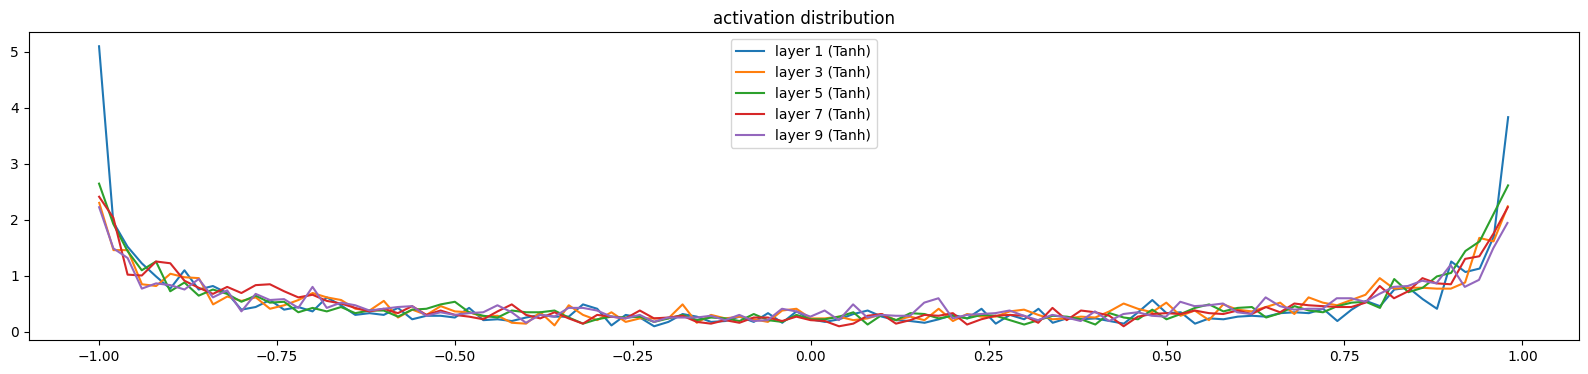

In [138]:
# visualize histograms
plt.figure(figsize = (20,4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # exclude the output layer
    if isinstance(layer, Tanh):
        t = layer.out
        print("layer %d (%10s) : mean % +.2f, std %.2f, saturated: %.2f%%" %(i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
        hy, hx = torch.histogram(t, density = True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f"layer {i} ({layer.__class__.__name__})")
plt.legend(legends);
plt.title("activation distribution")

layer 1 (      Tanh) : mean -0.00, std 0.00, saturated: 0.00%
layer 3 (      Tanh) : mean +0.00, std 0.00, saturated: 0.00%
layer 5 (      Tanh) : mean -0.00, std 0.00, saturated: 0.00%
layer 7 (      Tanh) : mean +0.00, std 0.00, saturated: 0.00%
layer 9 (      Tanh) : mean +0.00, std 0.00, saturated: 0.00%


Text(0.5, 1.0, 'gradient distribution')

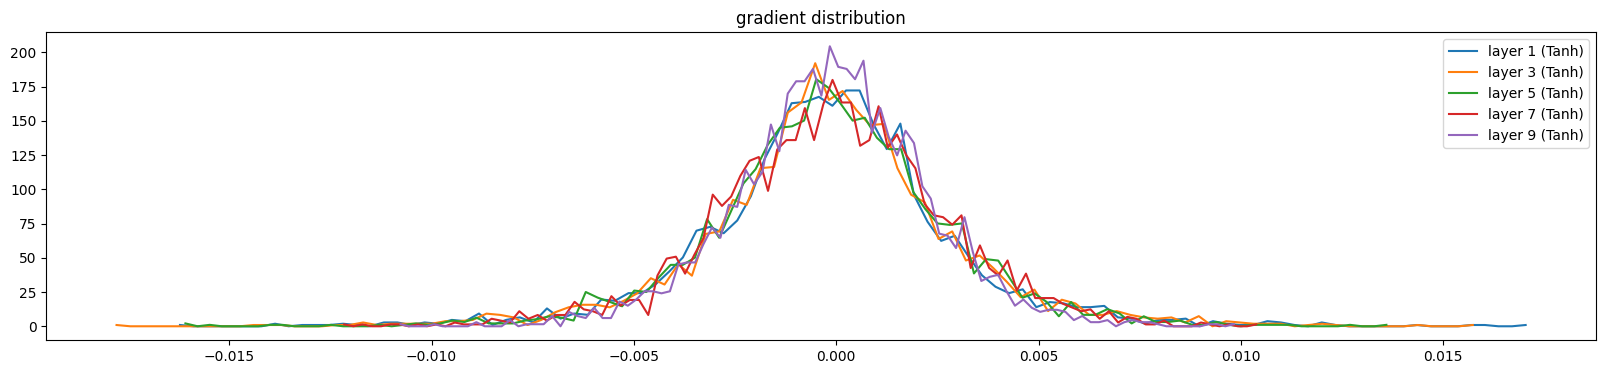

In [139]:
# visualize histograms
plt.figure(figsize = (20,4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # exclude the output layer
    if isinstance(layer, Tanh):
        t = layer.out.grad
        print("layer %d (%10s) : mean % +.2f, std %.2f, saturated: %.2f%%" %(i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
        hy, hx = torch.histogram(t, density = True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f"layer {i} ({layer.__class__.__name__})")
plt.legend(legends);
plt.title("gradient distribution")

weight   (27, 10)  | mean +0.000772  | std 9.714618e-03 | grad:data ratio 9.714504e-03
weight  (30, 100)  | mean -0.000036  | std 8.734046e-03 | grad:data ratio 2.792835e-02
weight (100, 100)  | mean +0.000085  | std 7.424626e-03 | grad:data ratio 4.417371e-02
weight (100, 100)  | mean +0.000055  | std 6.242014e-03 | grad:data ratio 3.681917e-02
weight (100, 100)  | mean +0.000007  | std 6.161664e-03 | grad:data ratio 3.650615e-02
weight (100, 100)  | mean +0.000069  | std 5.222000e-03 | grad:data ratio 3.102275e-02
weight  (100, 27)  | mean +0.000000  | std 2.281147e-02 | grad:data ratio 3.229574e-01


Text(0.5, 1.0, 'weights gradient distribution')

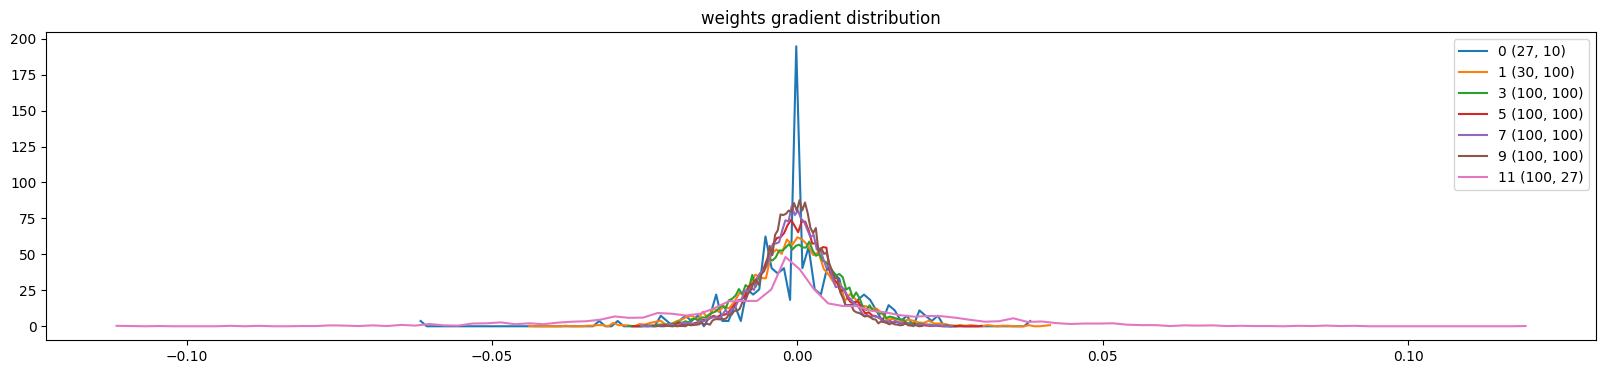

In [140]:
# visualize histograms
plt.figure(figsize = (20,4)) # width and height of the plot
legends = []
for i, p in enumerate(parameters):
    t = p.grad
    if p.ndim == 2:
        print("weight %10s  | mean %+f  | std %e | grad:data ratio %e" % (tuple(p.shape), t.mean(), t.std(), t.std()/p.std() ))
        hy, hx = torch.histogram(t, density = True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f"{i} {tuple(p.shape)}")
plt.legend(legends)
plt.title("weights gradient distribution")


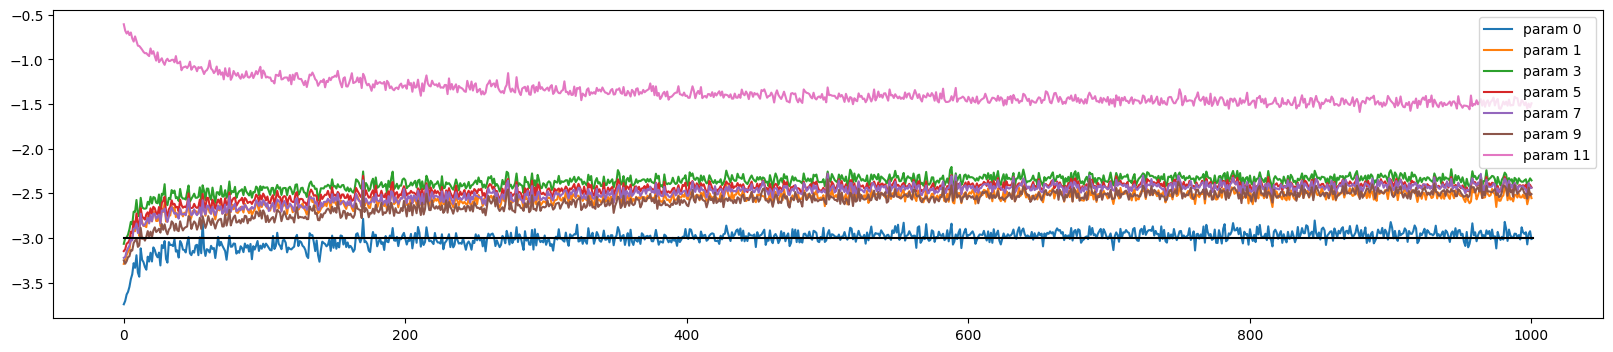

In [141]:
plt.figure(figsize = (20,4))
legends = []
for i, p in enumerate(parameters):
    if p.ndim == 2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append("param %d" % i)
plt.plot([0, len(ud)], [-3, -3], "k")
plt.legend(legends)

In [115]:
ix = torch.randint(0, Xtr.shape[0], (batch_size, ), generator = g)
Xtr.shape

torch.Size([182625, 3])

In [80]:
C[torch.tensor([[1,1],[2,2]])][0,0,:]

tensor([-0.4713,  0.7868, -0.3284, -0.4330,  1.3729,  2.9334,  1.5618, -1.6261,
         0.6772, -0.8404])

In [130]:
parameters[0].ndim

2

### Introducing batch norm now

More robust to the scaling of the weight initialization (not immune)

In [ ]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 100 # the number of neurons in the hidden layer of the MLP
g = torch.Generator().manual_seed(2147483647) # for reproductibility

C = torch.randn((vocab_size, n_embd),                 generator = g)
layers = [
    Linear(n_embd* block_size, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(          n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(          n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(          n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(          n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(          n_hidden, vocab_size), BatchNorm1d(vocab_size),
]

with torch.no_grad():
    # last layer: make less confident
    layers[-1].gamma *= 0.1 # variable in batchnorm
    # all other layers: apply gain
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 1.0 #5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad =True


47551


In [159]:
# same optimization as last time:
max_steps= 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):

    #minibatch contruct
    ix = torch.randint(0, Xtr.shape[0], (batch_size, ), generator = g)
    Xb, Yb = Xtr[ix] , Ytr[ix] # batch X, Y

    # forward pass
    emb = C[Xb] # embed the characters into vectors
    x = emb.view(emb.shape[0], -1) # concatenate the vectors
    for layer in layers:
       x = layer(x)
    loss = F.cross_entropy(x, Yb) # loss function

    # backward pass
    for layer in layers:
        layer.out.retain_grad() # AFTER DEBUG: wold take out retain_graph
    for p in parameters:
        p.grad = None
    loss.backward()

    #update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0: # print every once in a while
        print(f"{i:7d}/ {max_steps:7d}: {loss.item():.4f}")
    lossi.append(loss.log10().item())
    with torch.no_grad():
        ud.append([(lr*p.grad.std() / p.data.std()).log10().item() for p in parameters])

    if i >= 1000:
        break # After debuf: would take out obviously to run full optimization



      0/  200000: 3.2870


layer 2 (      Tanh) : mean -0.00, std 0.64, saturated: 2.56%
layer 5 (      Tanh) : mean +0.00, std 0.66, saturated: 2.00%
layer 8 (      Tanh) : mean +0.00, std 0.66, saturated: 1.47%
layer 11 (      Tanh) : mean +0.00, std 0.66, saturated: 1.22%
layer 14 (      Tanh) : mean -0.00, std 0.66, saturated: 0.72%


Text(0.5, 1.0, 'activation distribution')

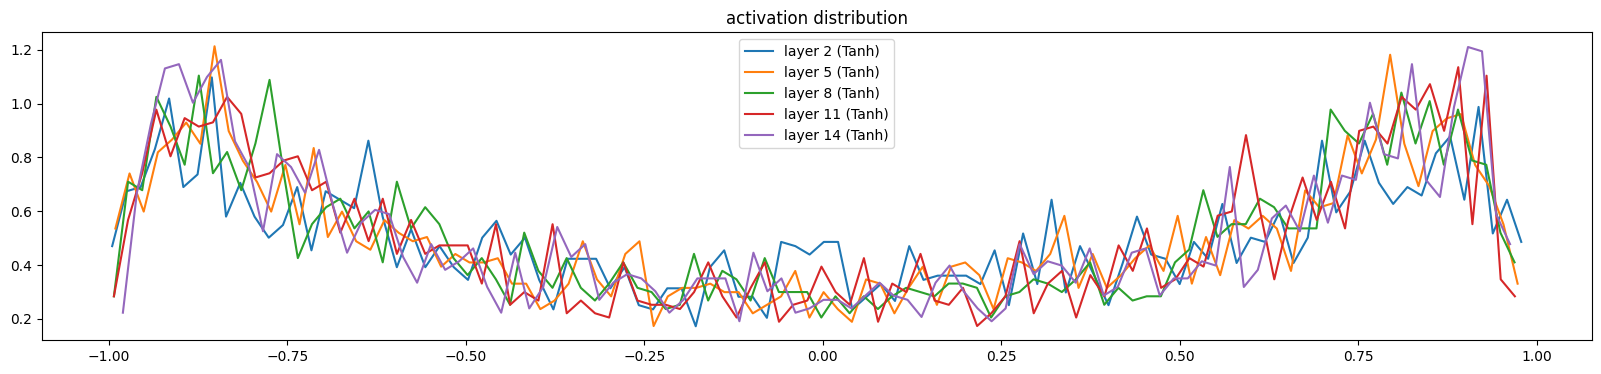

In [160]:
# visualize histograms
plt.figure(figsize = (20,4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # exclude the output layer
    if isinstance(layer, Tanh):
        t = layer.out
        print("layer %d (%10s) : mean % +.2f, std %.2f, saturated: %.2f%%" %(i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
        hy, hx = torch.histogram(t, density = True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f"layer {i} ({layer.__class__.__name__})")
plt.legend(legends);
plt.title("activation distribution")

layer 2 (      Tanh) : mean -0.00, std 0.00, saturated: 0.00%
layer 5 (      Tanh) : mean -0.00, std 0.00, saturated: 0.00%
layer 8 (      Tanh) : mean +0.00, std 0.00, saturated: 0.00%
layer 11 (      Tanh) : mean +0.00, std 0.00, saturated: 0.00%
layer 14 (      Tanh) : mean -0.00, std 0.00, saturated: 0.00%


Text(0.5, 1.0, 'gradient distribution')

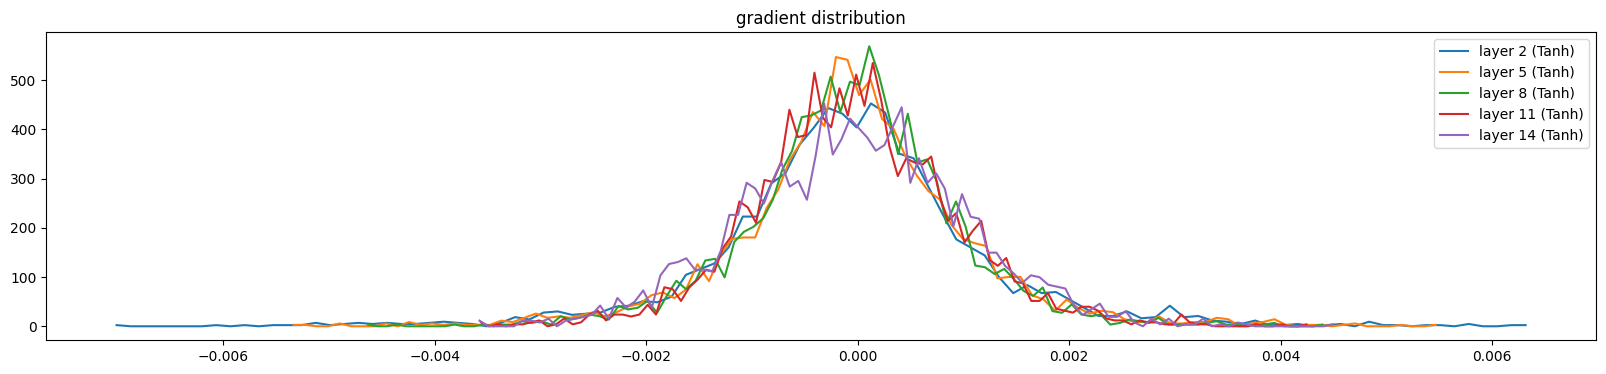

In [161]:
# visualize histograms
plt.figure(figsize = (20,4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # exclude the output layer
    if isinstance(layer, Tanh):
        t = layer.out.grad
        print("layer %d (%10s) : mean % +.2f, std %.2f, saturated: %.2f%%" %(i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
        hy, hx = torch.histogram(t, density = True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f"layer {i} ({layer.__class__.__name__})")
plt.legend(legends);
plt.title("gradient distribution")

weight   (27, 10)  | mean +0.000000  | std 7.373113e-03 | grad:data ratio 7.366234e-03
weight  (30, 100)  | mean +0.000311  | std 1.391911e-02 | grad:data ratio 2.291526e-01
weight (100, 100)  | mean +0.000029  | std 6.005465e-03 | grad:data ratio 2.009057e-01
weight (100, 100)  | mean -0.000016  | std 5.219674e-03 | grad:data ratio 1.905852e-01
weight (100, 100)  | mean -0.000050  | std 5.058500e-03 | grad:data ratio 1.921143e-01
weight (100, 100)  | mean -0.000113  | std 5.221358e-03 | grad:data ratio 2.003029e-01
weight  (100, 27)  | mean +0.000016  | std 1.234923e-02 | grad:data ratio 2.863963e-01


Text(0.5, 1.0, 'weights gradient distribution')

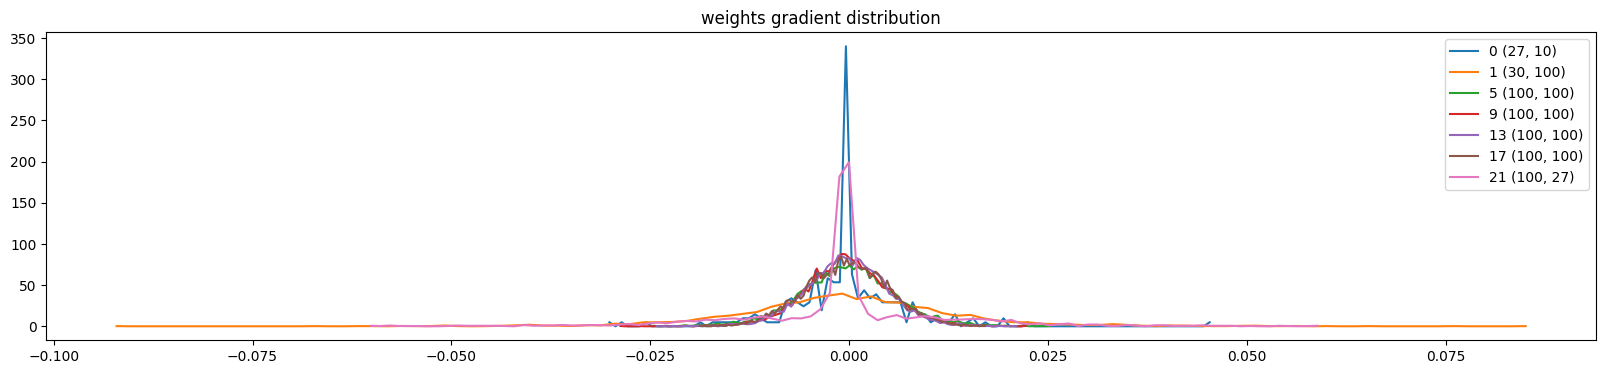

In [162]:
# visualize histograms
plt.figure(figsize = (20,4)) # width and height of the plot
legends = []
for i, p in enumerate(parameters):
    t = p.grad
    if p.ndim == 2:
        print("weight %10s  | mean %+f  | std %e | grad:data ratio %e" % (tuple(p.shape), t.mean(), t.std(), t.std()/p.std() ))
        hy, hx = torch.histogram(t, density = True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f"{i} {tuple(p.shape)}")
plt.legend(legends)
plt.title("weights gradient distribution")


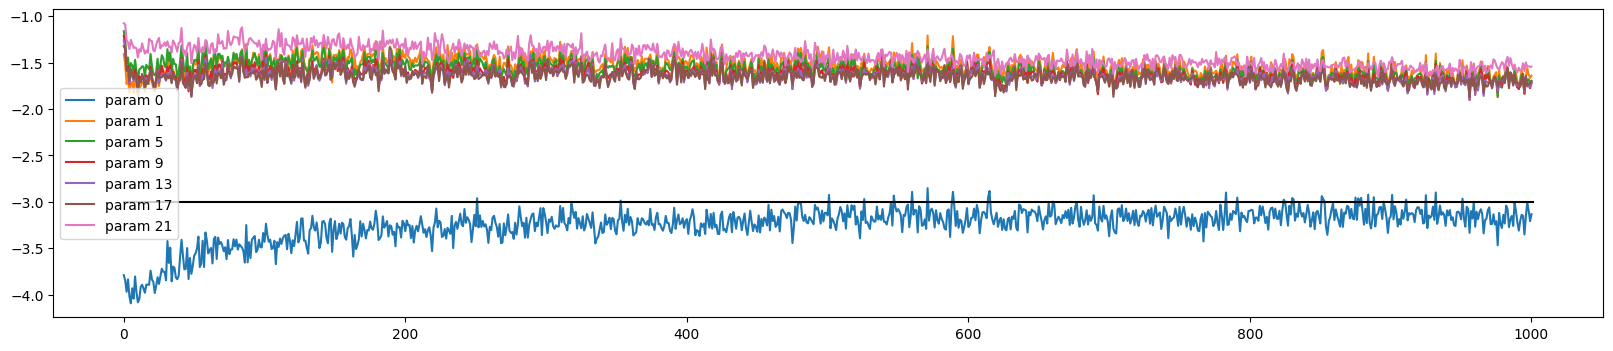

In [163]:
plt.figure(figsize = (20,4))
legends = []
for i, p in enumerate(parameters):
    if p.ndim == 2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append("param %d" % i)
plt.plot([0, len(ud)], [-3, -3], "k")
plt.legend(legends)